# Experiments with JOHD dataset


Author: Barbara McGillivray, June 2024

This notebook contains some experiments in linking data papers and reseaarch papers using the dataset of JOHD and RDJ papers curated for the Deep Impact article (https://www.mdpi.com/2304-6775/10/4/39).

## Read input

Use curated dataset from https://drive.google.com/file/d/1Yvm5mhYHjPJS-a1dankCC9eI_TNKBZ6O/view?usp=drive_link, which was expanded from Jade's dataset (https://docs.google.com/spreadsheets/d/1AINM2E8M3IxCjGI8XId3Ig5x27yhybuI8TLK7hvzyqk/edit?pli=1&gid=0#gid=0).

In [10]:
import pandas as pd
# Read the Excel file
curated = pd.read_csv("links_with_complete_details.csv")

# Display the first few rows of the data frame:
print(curated.head())


   Unnamed: 0  data_paper_doi             research_paper_doi  \
0           0  10.5334/johd.1   10.1080/03071022.2014.975943   
1           1  10.5334/johd.1  10.1080/01615440.2015.1007194   
2           2  10.5334/johd.4          10.1353/shq.2015.0000   
3           3  10.5334/johd.4      10.22230/src.2014v5n4a187   
4           4  10.5334/johd.6                10.16995/olh.82   

                                      data_paper_url  \
0  https://openhumanitiesdata.metajnl.com/article...   
1  https://openhumanitiesdata.metajnl.com/article...   
2  https://openhumanitiesdata.metajnl.com/article...   
3  https://openhumanitiesdata.metajnl.com/article...   
4  https://openhumanitiesdata.metajnl.com/article...   

                                  research_paper_url  \
0  https://www.tandfonline.com/doi/full/10.1080/0...   
1  https://www.tandfonline.com/doi/full/10.1080/0...   
2  https://academic.oup.com/sq/article/66/1/1-28/...   
3  https://src-online.ca/index.php/src/article/vi...  

In [11]:
curated.shape

(80, 17)

Column names

In [12]:
# Extract column names and convert to a list
column_names_list = curated.columns.tolist()

# Print the list of column names
print(column_names_list)

['Unnamed: 0', 'data_paper_doi', 'research_paper_doi', 'data_paper_url', 'research_paper_url', 'research_paper_file_url', 'data_paper_has_file', 'research_paper_has_file', 'source', 'all_author_names_data_paper', 'all_author_names_research_paper', 'matching_authors', 'non_matching_authors', 'proportion_of_authors_found', 'data_paper_publication_date', 'research_paper_publication_date', 'days_between_publications']


Summary and overview of the data frame:

In [13]:
curated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       80 non-null     int64  
 1   data_paper_doi                   80 non-null     object 
 2   research_paper_doi               80 non-null     object 
 3   data_paper_url                   29 non-null     object 
 4   research_paper_url               29 non-null     object 
 5   research_paper_file_url          20 non-null     object 
 6   data_paper_has_file              80 non-null     bool   
 7   research_paper_has_file          80 non-null     bool   
 8   source                           80 non-null     object 
 9   all_author_names_data_paper      80 non-null     object 
 10  all_author_names_research_paper  80 non-null     object 
 11  matching_authors                 79 non-null     object 
 12  non_matching_authors    

In [14]:
curated.describe()

,Unnamed: 0,proportion_of_authors_found,days_between_publications
count,80.0000,80.000000,75.000000
mean,39.5000,0.520791,226.480000
std,23.2379,0.308852,239.866143
min,0.0000,0.000000,0.000000
25%,19.7500,0.276786,78.000000
50%,39.5000,0.500000,157.000000
75%,59.2500,0.783333,281.500000
max,79.0000,1.000000,1240.000000


## Match data papers with research papers based on title and author similarity

Map DOIs. NB: this assumes only one research paper per data paper:

In [18]:
datapaper2researchpaper = dict(zip(curated['data_paper_doi'], curated['research_paper_doi']))
datapaper2researchpaper

{'10.5334/johd.1': '10.1080/01615440.2015.1007194',
 '10.5334/johd.4': '10.22230/src.2014v5n4a187',
 '10.5334/johd.6': '10.16995/olh.82',
 '10.5334/johd.8': '10.1080/13555502.2017.1301178',
 '10.5334/johd.9': '10.3389/frma.2018.00021',
 '10.5334/johd.11': '10.4324/9781315268323-10',
 '10.5334/johd.13': '10.1515/opli-2016-0026',
 '10.5334/johd.12': '10.1075/dia.20009.bod',
 '10.5334/johd.14': '10.1353/mns.2018.0012',
 '10.5334/johd.17': '10.3390/informatics7040044',
 '10.5334/johd.21': '10.1093/jamiaopen/ooab089',
 '10.5334/johd.20': '10.4324/9780203728628-7',
 '10.5334/johd.22': '10.1093/llc/fqab032',
 '10.5334/johd.25': '10.1515/lingvan-2021-0053',
 '10.5334/johd.32': '10.5334/johd.31',
 '10.5334/johd.33': 'http://ceur-ws.org/Vol-2723/short26.pdf',
 '10.5334/johd.30': 'http://ceur-ws.org/Vol-2723/long7.pdf',
 '10.5334/johd.35': '10.1007/978-3-658-30702-8_7',
 '10.5334/johd.45': '10.6084/m9.figshare.14743044.v2',
 '10.5334/johd.49': '10.1080/23273798.2018.1552007',
 '10.5334/johd.56': 

Get articles' text:

In [16]:
import requests
from difflib import SequenceMatcher

Function to get metadata from CrossRef API:

In [56]:
def get_metadata_from_api(doi):
    url = f"https://api.crossref.org/works/{doi}"
    headers = {'Accept': 'application/json'}
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an exception for bad responses
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"\tRequest failed for DOI {doi}: {e}")
        return None


Function to extract authors:

In [57]:
def extract_authors(metadata):
    authors = []
    if 'message' in metadata and 'author' in metadata['message']:
        for author in metadata['message']['author']:
            full_name = ""
            if 'given' in author:
                full_name += author['given'] + " "
            if 'family' in author:
                full_name += author['family']
            if full_name.strip():  # Ensure there's a non-empty name
                authors.append(full_name.strip())
    return authors


Extract metadata for one DOI as an example:

In [45]:
data_paper_doi = '10.5334/johd.14'
data_paper_metadata = get_metadata_from_api(data_paper_doi)
data_paper_title = data_paper_metadata['message']['title'][0]
data_paper_authors = extract_authors(data_paper_metadata)
data_paper_metadata

{'status': 'ok',
 'message-type': 'work',
 'message-version': '1.0.0',
 'message': {'indexed': {'date-parts': [[2023, 11, 19]],
   'date-time': '2023-11-19T08:48:42Z',
   'timestamp': 1700383722005},
  'reference-count': 5,
  'publisher': 'Ubiquity Press, Ltd.',
  'license': [{'start': {'date-parts': [[2020, 1, 1]],
     'date-time': '2020-01-01T00:00:00Z',
     'timestamp': 1577836800000},
    'content-version': 'vor',
    'delay-in-days': 0,
    'URL': 'http://creativecommons.org/licenses/by/4.0'}],
  'content-domain': {'domain': [], 'crossmark-restriction': False},
  'short-container-title': [],
  'published-print': {'date-parts': [[2020, 6, 11]]},
  'DOI': '10.5334/johd.14',
  'type': 'journal-article',
  'created': {'date-parts': [[2020, 6, 11]],
   'date-time': '2020-06-11T11:30:36Z',
   'timestamp': 1591875036000},
  'source': 'Crossref',
  'is-referenced-by-count': 4,
  'title': ['Mapping Manuscript Migrations Knowledge Graph: Data for Tracing the History and Provenance of Medi

In [46]:
data_paper_title

'Mapping Manuscript Migrations Knowledge Graph: Data for Tracing the History and Provenance of Medieval and Renaissance Manuscripts'

In [47]:
data_paper_authors

['Toby Burrows',
 'Doug Emery',
 'Mitch Fraas',
 'Eero Hyvönen',
 'Esko Ikkala',
 'Mikko Koho',
 'David Lewis',
 'Andrew Morrison',
 'Kevin Page',
 'Lynn Ransom',
 'Emma Thomson',
 'Jouni Tuominen',
 'Athanasios Velios',
 'Hanno Wijsman']

Generate list of data paper titles and research paper titles:

In [94]:
paper2title = dict()
paper2authors = dict()
total_dois = len(datapaper2researchpaper)
processed_count = 0

for datapaper_doi in datapaper2researchpaper:
    researchpaper_doi = datapaper2researchpaper[datapaper_doi]
    processed_count += 1
    print(f"Processed {processed_count} out of {total_dois} DOIs")
    #print(datapaper_doi, researchpaper_doi)
    
    # data paper:
    datapaper_metadata = get_metadata_from_api(datapaper_doi)
    if datapaper_metadata:
        datapaper_title = datapaper_metadata['message']['title'][0]
        datapaper_authors = extract_authors(datapaper_metadata)
        paper2title[datapaper_doi] = datapaper_title
        paper2authors[datapaper_doi] = datapaper_authors
    else:
        print(f"\tFailed to retrieve metadata for DOI: {data_paper_doi}.----")
        
    # research paper:
    researchpaper_metadata = get_metadata_from_api(researchpaper_doi)
    if researchpaper_metadata:
        paper_title = researchpaper_metadata['message']['title'][0]
        paper_authors = extract_authors(researchpaper_metadata)
        paper2title[researchpaper_doi] = paper_title
        paper2authors[researchpaper_doi] = paper_authors
    else:
        print(f"\tFailed to retrieve metadata for DOI: {researchpaper_doi}.---")


Processed 1 out of 72 DOIs
Processed 2 out of 72 DOIs
Processed 3 out of 72 DOIs
Processed 4 out of 72 DOIs
Processed 5 out of 72 DOIs
Processed 6 out of 72 DOIs
Processed 7 out of 72 DOIs
Processed 8 out of 72 DOIs
Processed 9 out of 72 DOIs
Processed 10 out of 72 DOIs
Processed 11 out of 72 DOIs
Processed 12 out of 72 DOIs
Processed 13 out of 72 DOIs
Processed 14 out of 72 DOIs
Processed 15 out of 72 DOIs
Processed 16 out of 72 DOIs
Request failed for DOI http://ceur-ws.org/Vol-2723/short26.pdf: 404 Client Error: Not Found for url: https://api.crossref.org/works/http://ceur-ws.org/Vol-2723/short26.pdf
	Failed to retrieve metadata for DOI: http://ceur-ws.org/Vol-2723/short26.pdf.---
Processed 17 out of 72 DOIs
Request failed for DOI http://ceur-ws.org/Vol-2723/long7.pdf: 404 Client Error: Not Found for url: https://api.crossref.org/works/http://ceur-ws.org/Vol-2723/long7.pdf
	Failed to retrieve metadata for DOI: http://ceur-ws.org/Vol-2723/long7.pdf.---
Processed 18 out of 72 DOIs
Pro

Similarity function: calculates the similarity ratio between two strings based on their common subsequence lengths. It focuses on the length of the longest common subsequence. The similarity ratio is a float between 0 and 1 representing the proportion of common subsequence length to total string length.

In [95]:
import re
def similarity(title1, title2):
    # Preprocess titles (lowercase and remove non-alphanumeric characters)
    title1_processed = re.sub(r'\W+', ' ', title1.lower()).strip()
    title2_processed = re.sub(r'\W+', ' ', title2.lower()).strip()

    return SequenceMatcher(None, title1_processed, title2_processed).ratio()

I calculate the similarity between the titles of data papers and associated research papers:

In [104]:
# List of similarity values between titles of data papers and their associated research papers:

title_similarities_pairs = list()
# Iterating through each data paper DOI
for datapaper_doi in datapaper2researchpaper:
    if datapaper2researchpaper[datapaper_doi]:
        researchpaper_doi = datapaper2researchpaper[datapaper_doi]
        #print("Comparing", datapaper_doi, "with", researchpaper_doi)
        if datapaper_doi in paper2title and researchpaper_doi in paper2title:
            datapaper_title = paper2title[datapaper_doi]
            researchpaper_title = paper2title[researchpaper_doi]
            #print("\tComparing titles", datapaper_title, "\n\twith\n\t", researchpaper_title)
    
        
            # Calculate title similarity
            title_similarity = similarity(datapaper_title, researchpaper_title)
            title_similarities_pairs.append(title_similarity)
        
            # Print similarity ratio
            print(f"Similarity between '{datapaper_title}' and '{researchpaper_title}': {title_similarity}")
        else:
            print(f"Titles not found for DOI pair: {datapaper_doi} and {datapaper2researchpaper.get(datapaper_doi)}")

Similarity between 'Vagrant Lives: 14,789 Vagrants Processed by the County of Middlesex, 1777–1786' and 'A Comparative Approach to Identifying the Irish in Long Eighteenth-Century London': 0.34394904458598724
Similarity between 'Writing About Shakespeare: 1960–2010' and 'Digital Bibliography and Global Shakespeare': 0.48717948717948717
Similarity between 'JSON-Encoded Textual Variance Between the Published Versions of David Mitchell’s Cloud Atlas in “an Orison of Sonmi ~451”' and '“You have to keep track of your changes”: The Version Variants and Publishing History of David Mitchell's Cloud Atlas': 0.46551724137931033
Similarity between 'Scissors and Paste: The Georgian Reprints, 1800–1837' and 'Stuck in the Middle: Developing Research Workflows for a Multi-scale Text Analysis': 0.22900763358778625
Similarity between 'Annotated References in the Historiography on Venice: 19th–21st centuries' and 'Deep Reference Mining From Scholarly Literature in the Arts and Humanities': 0.38356164383

Summary stats of the similarities between paired titles:

In [105]:
import numpy as np
mean = np.mean(title_similarities_pairs)
median = np.median(title_similarities_pairs)
std_dev = np.std(title_similarities_pairs)
minimum = np.min(title_similarities_pairs)
maximum = np.max(title_similarities_pairs)
q1, q2, q3 = np.percentile(title_similarities_pairs, [25, 50, 75])

# Print summary statistics
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std_dev}")
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")
print(f"Q1 (25th percentile): {q1}")
print(f"Q2 (50th percentile - Median): {q2}")
print(f"Q3 (75th percentile): {q3}")

Mean: 0.3654947535361539
Median: 0.3455393446543889
Standard Deviation: 0.1306126806240255
Minimum: 0.11518324607329843
Maximum: 0.8744939271255061
Q1 (25th percentile): 0.27625
Q2 (50th percentile - Median): 0.3455393446543889
Q3 (75th percentile): 0.4262525562372188


Histogram of similarities between paired titles:

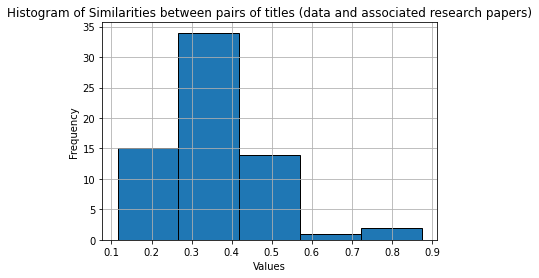

In [106]:
import matplotlib.pyplot as plt

# Plotting the histogram
plt.hist(title_similarities_pairs, bins=5, edgecolor='black')  # Adjust bins for desired number of bins
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Similarities between pairs of titles (data and associated research papers)')
plt.grid(True)
plt.show()

I calculate the similarity between the titles of random pairs of data papers and research papers:

In [107]:
import random
title_similarities_random = list()
# Extract lists of DOIs
data_paper_dois = list(datapaper2researchpaper.keys())
research_paper_dois = list(datapaper2researchpaper.values())

# Determine the number of pairs you want (adjust as needed)
num_pairs = len(datapaper2researchpaper.keys())

# Generate random pairs
random_pairs = [(random.choice(data_paper_dois), random.choice(research_paper_dois)) for _ in range(num_pairs)]

# Print random pairs
print("Random Pairs:")
for datapaper_doi, researchpaper_doi in random_pairs:
    print(f"Data Paper DOI: {data_doi} -> Research Paper DOI: {research_doi}")
    if datapaper_doi in paper2title and researchpaper_doi in paper2title:
        datapaper_title = paper2title[datapaper_doi]
        researchpaper_title = paper2title[researchpaper_doi]
        #print("\tComparing titles", datapaper_title, "\n\twith\n\t", researchpaper_title)
    
        # Calculate title similarity
        title_similarity = similarity(datapaper_title, researchpaper_title)
        title_similarities_random.append(title_similarity)
        
        # Print similarity ratio
        print(f"Similarity between '{datapaper_title}' and '{researchpaper_title}': {title_similarity}")
    else:
        print(f"Titles not found for DOI pair: {datapaper_doi} and {datapaper2researchpaper.get(datapaper_doi)}")

Random Pairs:
Data Paper DOI: 10.5334/johd.30 -> Research Paper DOI: 10.1353/mns.2018.0012
Similarity between 'The RETA Benchmark for Retinal Vascular Tree Analysis' and 'Mental simulation during literary reading: Individual differences revealed with eye-tracking': 0.2916666666666667
Data Paper DOI: 10.5334/johd.30 -> Research Paper DOI: 10.1353/mns.2018.0012
Similarity between 'Area of Habitat maps for the world’s terrestrial birds and mammals' and 'Climate signal strength in tree-ring width of spruce growing in the Solovetsky Islands (Russia)': 0.2893081761006289
Data Paper DOI: 10.5334/johd.30 -> Research Paper DOI: 10.1353/mns.2018.0012
Similarity between 'SOMAS: a platform for data-driven material discovery in redox flow battery development' and 'Evidence to support the mechanical advantage hypothesis of grasping at low force levels': 0.23255813953488372
Data Paper DOI: 10.5334/johd.30 -> Research Paper DOI: 10.1353/mns.2018.0012
Similarity between 'Data from ‘The Dative Alternati

Summary stats of the similarities between the titles of random pairs:

In [108]:
import numpy as np
mean = np.mean(title_similarities_random)
median = np.median(title_similarities_random)
std_dev = np.std(title_similarities_random)
minimum = np.min(title_similarities_random)
maximum = np.max(title_similarities_random)
q1, q2, q3 = np.percentile(title_similarities_random, [25, 50, 75])

# Print summary statistics
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std_dev}")
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")
print(f"Q1 (25th percentile): {q1}")
print(f"Q2 (50th percentile - Median): {q2}")
print(f"Q3 (75th percentile): {q3}")

Mean: 0.270580398279725
Median: 0.2708333333333333
Standard Deviation: 0.06452640890344623
Minimum: 0.0975609756097561
Maximum: 0.4093567251461988
Q1 (25th percentile): 0.2429163034001744
Q2 (50th percentile - Median): 0.2708333333333333
Q3 (75th percentile): 0.3044590643274854


Histogram of similarities between paired titles:

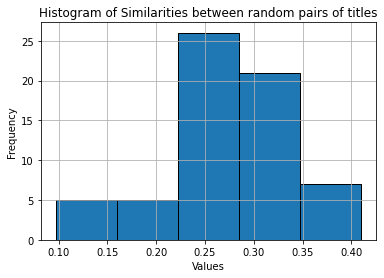

In [109]:
import matplotlib.pyplot as plt

# Plotting the histogram
plt.hist(title_similarities_random, bins=5, edgecolor='black')  # Adjust bins for desired number of bins
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Similarities between random pairs of titles')
plt.grid(True)
plt.show()

I conduct a Mann-Whitney U test between the two sets of lists:

In [110]:
from scipy import stats
# Perform Mann-Whitney U test
u_statistic, p_value = stats.mannwhitneyu(title_similarities_pairs, title_similarities_random, alternative='greater')

# Determine significance
alpha = 0.05  # significance level
if p_value < alpha:
    print(f"Paired list is significantly higher than Random list (p-value: {p_value})")
else:
    print(f"No significant difference between Paired list and Random list 2 (p-value: {p_value})")

Paired list is significantly higher than Random list (p-value: 7.098126572023398e-07)


STOPPED HERE

In [ ]:
author_overlap = set(data_paper_authors) & set(paper['authors'])